### Evaluation

In [ ]:
import pandas as pd
import numpy as np
import torch

run = "validation_result2"
#eval_sample = {'val-ecoli-5mCG':0, 'test-ecoli-5mCG':1}
eval_sample = {'':0, 'region2-wt':1}

eval_data = []
for sample in eval_sample.items():   
    data = pd.read_parquet(f"./validation/{run}-{sample[0]}.pq")
    if sample[1]>=0: 
        data['labels'] = sample[1]
    eval_data.append(data)
df = pd.concat(eval_data)

#Aggregation
def agg(df): 
    agg = df.groupby(["chrom", "ref_pos_0based", "strand", "labels"])["score_recon"].agg(["count","mean","std"]).reset_index()
    return agg
    
ag = pd.concat([agg(data) for data in eval_data])
#ag.to_csv("../evaluation/dna.hg004.full.region2.tsv", index=False, sep='\t')

In [3]:
def agg(df): 
    agg = df.groupby(["chrom", "ref_pos_0based", "strand", "labels"])["scores"].agg(["count","mean","std"]).reset_index()
    return agg
    
ag = pd.concat([agg(data) for data in eval_data])
ag.to_csv("../evaluation/dna.hg002.full.region2.tsv", index=False, sep='\t')

### Figures

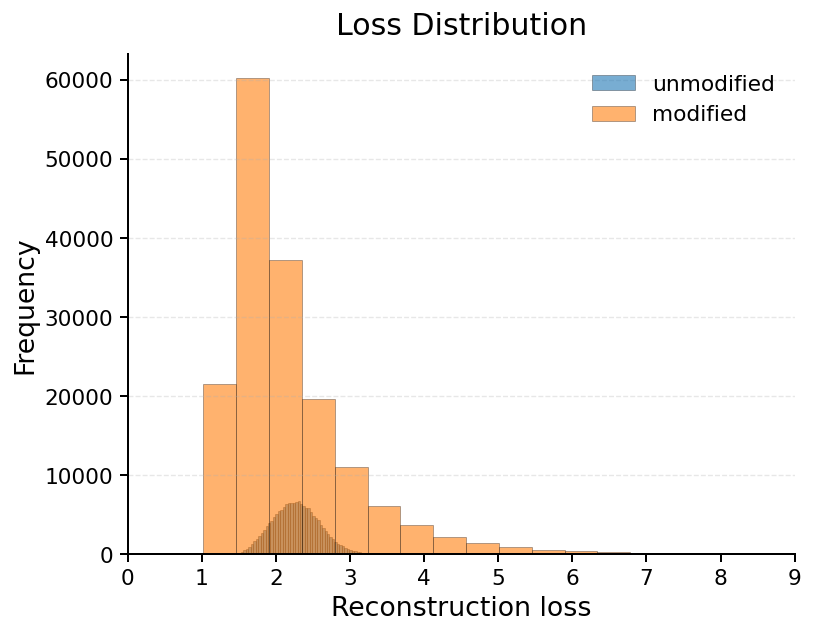

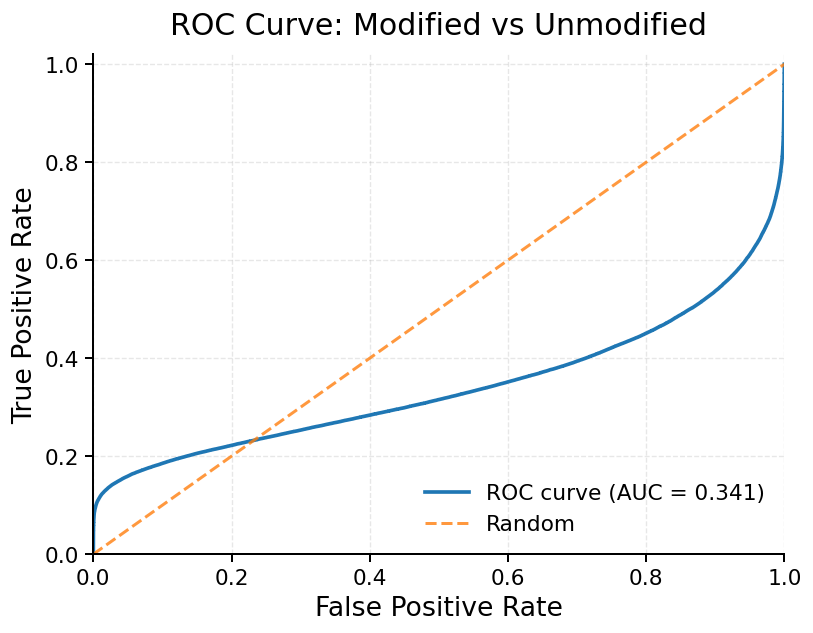

ROC AUC = 0.3412


In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def _set_plot_style():
    plt.rcParams.update({
        "figure.figsize": (7, 5.5),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 14,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "axes.linewidth": 1.2,
        "lines.linewidth": 2.2,
        "xtick.major.width": 1.2,
        "ytick.major.width": 1.2,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
    })

def plotROC(df, score_col, label_col, save_path='figures/ROC_latest.png'):
    _set_plot_style()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    fpr, tpr, thresholds = roc_curve(df[label_col], df[score_col])
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots()
    ax.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], '--', linewidth=1.8, alpha=0.8, label="Random")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve: Modified vs Unmodified", pad=12)

    ax.grid(True, linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc="lower right")

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print(f"ROC AUC = {roc_auc:.4f}")

def plotHist(df, score_col, label_col, save_path='figures/hist_latest.png'):
    _set_plot_style()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    fig, ax = plt.subplots()

    ax.hist(
        df.loc[df[label_col] == 0, score_col],
        bins=200,
        alpha=0.6,
        label='unmodified',
        edgecolor='black',
        linewidth=0.3
    )
    ax.hist(
        df.loc[df[label_col] == 1, score_col],
        bins=200,
        alpha=0.6,
        label='modified',
        edgecolor='black',
        linewidth=0.3
    )
    ax.set_xlim(0, 9)
    ax.set_xlabel("Reconstruction loss")
    ax.set_ylabel("Frequency")
    ax.set_title("Loss Distribution", pad=12)

    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

plotHist(df, 'score_recon', 'labels', save_path='figures/hist_hg2.png')
plotROC(df, 'score_recon', 'labels', save_path='figures/ROC_hg2.png')

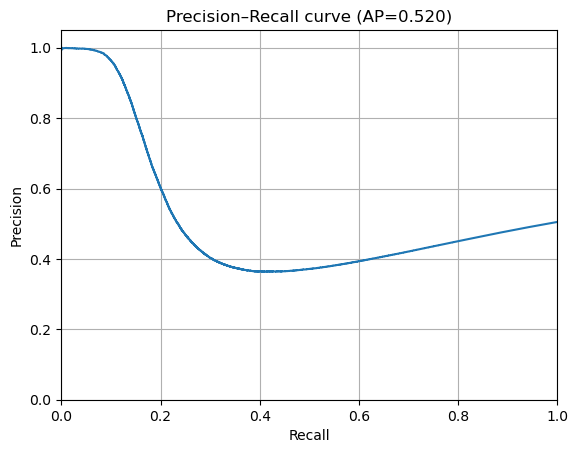

The precision at 0.95 recall is 0.3965


In [21]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import os
import numpy as np
import matplotlib.pyplot as plt

def _set_plot_style():
    plt.rcParams.update({
        "figure.figsize": (7, 5.5),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 14,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "axes.linewidth": 1.2,
        "lines.linewidth": 2.2,
        "xtick.major.width": 1.2,
        "ytick.major.width": 1.2,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
    })

def plot_pr_curve(scores, labels, title="Precision–Recall Curve",
                  save_path="./figures/PRC_latest.png"):
    _set_plot_style()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    scores = np.asarray(scores).ravel()
    labels = np.asarray(labels).astype(int).ravel()

    precision, recall, thresholds = precision_recall_curve(labels, scores)
    ap = average_precision_score(labels, scores)

    fig, ax = plt.subplots()

    ax.plot(recall, precision, label=f"PR curve (AP = {ap:.3f})")

    baseline = labels.mean()
    ax.axhline(baseline, linestyle="--", linewidth=1.8, alpha=0.8,
               label=f"Baseline ({baseline:.3f})")

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title, pad=12)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.05)

    ax.grid(True, linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc="lower left")

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    print(f"Average Precision = {ap:.4f}")

plot_pr_curve(df['score_recon'], df['labels'], save_path="./figures/PRC_hg2.png")

def precision_at_threshold(scores, labels, recall):
    threshold = torch.quantile(torch.Tensor(scores[labels == 0].values), 1.0-recall)
    scores = torch.Tensor(scores.values)
    labels = torch.Tensor(labels.values)
    preds = (scores >= threshold).long()  # predicted anomalies

    tp = ((preds == 1) & (labels == 1)).sum().item()
    fp = ((preds == 1) & (labels == 0)).sum().item()

    precision = tp / (tp + fp + 1e-8)
    return precision

target_recall = 0.95
prec = precision_at_threshold(df['score_recon'], df['labels'], target_recall)
print(f"The precision at {target_recall} recall is {prec:.4f}")

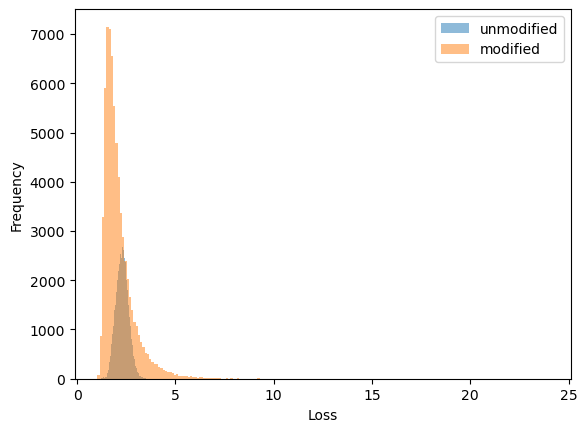

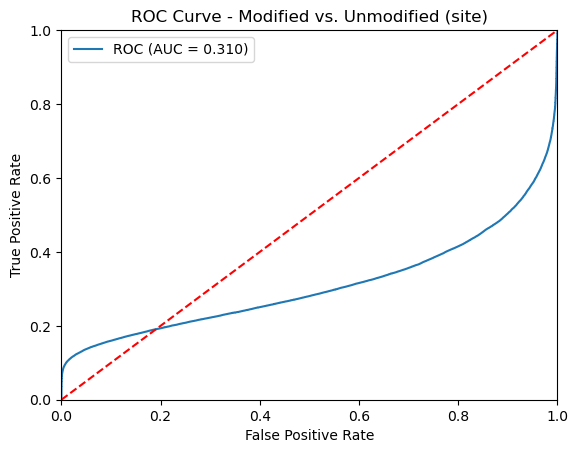

ROC AUC = 0.3101


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

def plotROC(df, score_col, label_col):
    fpr, tpr, thresholds = roc_curve(df[label_col], df[score_col])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
    plt.plot([0,1],[0,1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Modified vs. Unmodified (site)")
    plt.legend()
    plt.savefig('figures/ROC_site_latest.png', dpi=300)
    plt.show()
    print(f"ROC AUC = {roc_auc:.4f}")
    
def plotHist(df, score_col, label_col):
    plt.hist(df.loc[df[label_col]==0,score_col], bins=200, alpha=0.5, label='unmodified');
    plt.hist(df.loc[df[label_col]==1,score_col], bins=200, alpha=0.5, label='modified');
    #plt.xlim([0, 0.2])
    #plt.ylim([0, 1])
    plt.xlabel("Loss")
    plt.ylabel("Frequency")
    plt.legend()
    plt.savefig('figures/hist_site_latest.png', dpi=300)
    plt.show()

plotHist(ag, 'mean', 'labels')
plotROC(ag, 'mean', 'labels')

/tmp/ipykernel_1824626/65557501.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("./figures/site-bar_latest.png", dpi=300)
/home/zouy1/miniconda3/envs/deepmod2/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


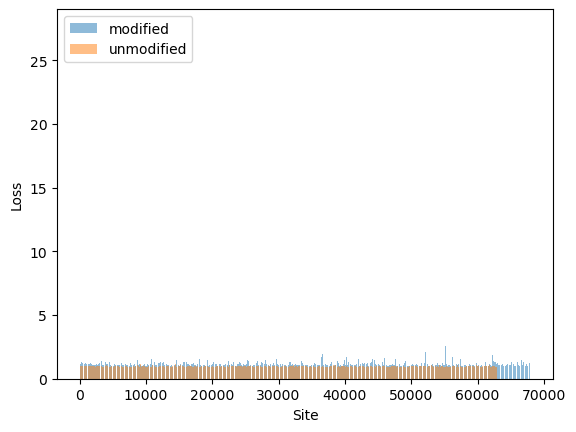

In [11]:
def plotBar(df, score_col, label_col):
    score_site0 = df.loc[df[label_col]==0,score_col]
    score_site1 = df.loc[df[label_col]==1,score_col]
    plt.bar(list(range(len(score_site1))), score_site1, alpha=0.5, label='modified');
    plt.bar(list(range(len(score_site0))), score_site0, alpha=0.5, label='unmodified');
    plt.xlabel("Site")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig("./figures/site-bar_latest.png", dpi=300)
    plt.show()

plotBar(ag, 'mean', 'labels')

In [4]:
#per k-mer evaluation
base_map = {0: "A", 1: "C", 2: "G", 3: "T"}

def kmer_from_window(x):
    idx = x[:, :4].argmax(dim=1).cpu().numpy()
    return "".join(base_map[int(i)] for i in idx)

def evaluate_per_kmer(model, loader, device="cuda"):
    model.eval()
    loss_dict = defaultdict(list)

    with torch.no_grad():
        for x, lb, pos in loader:
            x = x.to(device)
            out = model(x)
            recon_score = ((out["x_hat"] - x) ** 2).mean(dim=(1, 2))  # [B]

            # Decode k-mer for every datum in the batch
            for i in range(x.size(0)):
                kmer = kmer_from_window(x[i])
                loss_dict[kmer].append(float(recon_score[i].detach().cpu()))

    return loss_dict

# {kmer: [loss]}
un_loss = evaluate_per_kmer(model, test_loader)   
mod_loss= evaluate_per_kmer(model, mod_loader)

NameError: name 'model' is not defined

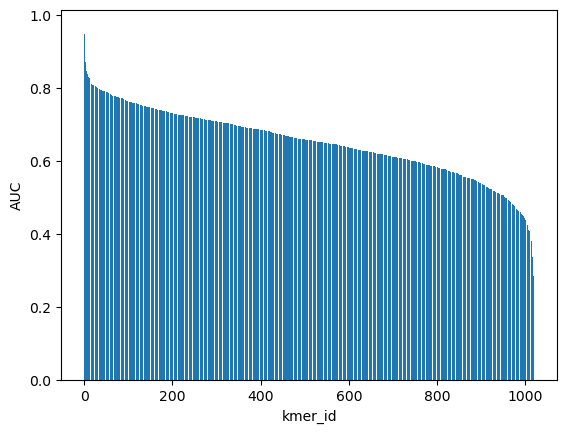

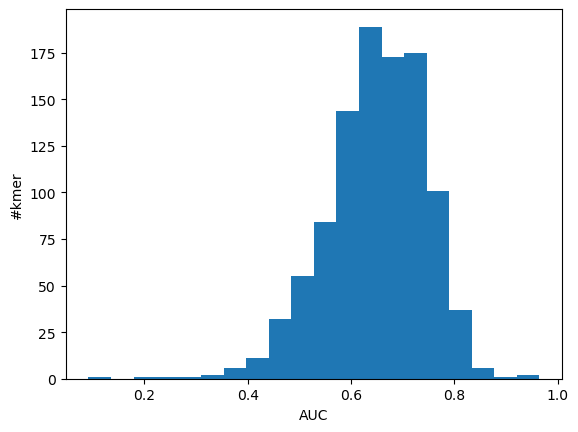

In [12]:
def ROCbykmer(un_loss, mod_loss):
    kmer_stats = []
    
    for km in un_loss.keys():
        un_arr = np.array(un_loss[km])
        mod_arr= np.array(mod_loss.get(km, []))
    
        if len(mod_arr) == 0: #skip kmers absent in mod set
            continue
    
        mean_un = un_arr.mean()
        mean_mod= mod_arr.mean()
    
        # ROC for this k-mer
        labels, scores = labscore(un_arr, mod_arr)
        fpr, tpr, thresholds = roc_curve(labels, scores)
        aucs = auc(fpr, tpr)
        kmer_stats.append((km, len(un_arr), len(mod_arr), mean_un, mean_mod, aucs))

    kmer_stats.sort(key=lambda t: t[-1], reverse=True)
    return pd.DataFrame(kmer_stats, columns=['kmer','#un','#mod','mean_un','mean_mod','auc'])
    
aucs = ROCbykmer(un_loss, mod_loss)

plt.bar(aucs.index, aucs.auc)
plt.xlabel("kmer_id")
plt.ylabel("AUC")
plt.savefig("kmer-bar_CNNtrans_b-3.png", dpi=300)
plt.show()

plt.hist(aucs.auc, bins=20)
plt.xlabel("AUC")
plt.ylabel("#kmer")
plt.savefig("kmer-auc_CNNtrans_b-3.png", dpi=300)
plt.show()

In [43]:
def evaluate_per_read(model, loader, device="cuda"):
    loss_list, label_list, pos_list = [], [], []
    model.eval()

    with torch.no_grad():
        for x, y, pos in loader:                 # batch
            x = x.to(device)
            out = model(x)
            recon_score = ((out["x_hat"] - x) ** 2).mean(dim=(1, 2))

            loss_list.extend(recon_score.detach().cpu().tolist())
            label_list.extend(y.cpu().tolist())
            pos_list.extend(pos.cpu().tolist())

    return loss_list, label_list, pos_list

# aggregate score by position
def aggregate_by_site(losses, labels, positions, agg="mean"):
    score_dict  = defaultdict(list)
    label_dict  = defaultdict(list)

    for s, l, p in zip(losses, labels, positions):
        ps = str(p[2])+'-'+str(p[1])
        score_dict[ps].append(s)
        label_dict[ps].append(l)

    site_score  = []
    site_label  = []

    for p in score_dict:
        vals = np.array(score_dict[p])
        if agg == "median":
            site_score.append(np.median(vals))
        elif agg == "max":
            site_score.append(np.max(vals))
        else:
            site_score.append(np.mean(vals))

        # majority vote for label, or "any-mod" rule
        lab = np.array(label_dict[p])
        site_label.append(int((lab == 1).any()))   # 1 if ≥1 mod read

    return np.array(site_score), np.array(site_label)

loss_r1, lab_r1, pos_r1 = evaluate_per_read(model, val_loader)
loss_r2, lab_r2, pos_r2 = evaluate_per_read(model, mod_loader)
pos_r = [list(t) for t in (set(map(tuple, pos_r1)) & set(map(tuple, pos_r2)))]
score_site1, label_site1 = aggregate_by_site(loss_r1, lab_r1, pos_r, agg="mean")
score_site2, label_site2 = aggregate_by_site(loss_r2, lab_r2, pos_r, agg="mean")
score_site = np.concat([score_site1, score_site2])
label_site = np.concat([label_site1, label_site2])

# ROC at site level
fpr, tpr, thresholds = roc_curve(label_site, score_site)
auc_site = auc(fpr, tpr)

print(f"Site-level ROC-AUC = {auc_site:.3f}  (N_sites = {len(score_site)})")

NameError: name 'test_loader' is not defined